# Fase 1 · EDA mínimo viable con `Titanic.csv`
## MCDI503 · Exploración Inteligente de Datos

**Integrantes:** Luis Díaz · Gonzalo Bouldres · Eduardo Contreras  
**Fecha:** 05/09/2026

### Propósito del notebook
Este notebook implementa el **diagnóstico exploratorio inicial** que acompaña la ficha del proyecto. Su objetivo no es cerrar el análisis ni construir modelos, sino dejar una base **ordenada, trazable y reproducible** para la entrega sumativa.

La secuencia sigue la lógica trabajada en el curso: **entender el contexto → revisar estructura → verificar calidad → resumir variables → observar relaciones simples → documentar hallazgos y decisiones**.

### Pregunta general
**¿Cómo se distribuye la supervivencia de los pasajeros del Titanic y qué patrones iniciales aparecen al compararla con características demográficas y del viaje?**

### Preguntas exploratorias
1. ¿Cuál es la proporción de supervivencia y cómo cambia según sexo?
2. ¿Existen diferencias de supervivencia entre las clases de pasajero?
3. ¿Cómo se distribuye la edad y qué diferencias descriptivas aparecen entre sobrevivientes y no sobrevivientes?
4. ¿Cómo se comporta la tarifa (`Fare`) y qué relación preliminar presenta con clase y supervivencia?
5. ¿El tamaño del grupo familiar, derivado de `SibSp` y `Parch`, muestra patrones que convenga profundizar?

### Alcance y supuestos iniciales
- Esta fase es **descriptiva y exploratoria**: no se realizan pruebas inferenciales ni modelos predictivos.
- `Survived` se interpreta como variable binaria (0 = no sobrevivió; 1 = sobrevivió).
- `Pclass` se interpreta como variable categórica ordinal, aunque esté almacenada como número.
- Los valores faltantes y posibles outliers **no se eliminan ni imputan automáticamente**: primero se identifican y documentan.
- Las asociaciones observadas no implican causalidad.

## 1. Entorno de trabajo, estructura de carpetas y reproducibilidad

El proyecto está preparado para ejecutarse en **Jupyter Notebook o JupyterLab** desde un entorno Python local. La organización separa las **entradas**, los **datos procesados**, las **figuras**, los **notebooks**, los **resultados** y los **reportes**, facilitando la trazabilidad y la reproducibilidad.

```text
├── data/
│   ├── input/
│   │   └── Titanic.csv
│   └── process/
├── figures/
├── notebooks/
│   └── mcdi503_f1f_eda_titanic.ipynb
├── outputs/
├── Reports/
├── requirements.txt
└── README.md
```

Criterios adoptados:
- `data/input/` contiene únicamente datos de entrada sin modificar.
- `data/process/` contiene datos derivados o transformados por código.
- `figures/` contiene todas las imágenes generadas por el notebook.
- `notebooks/` contiene el notebook ejecutable del proyecto.
- `outputs/` contiene tablas, resúmenes y otros resultados exportables.
- `Reports/` contiene los documentos de entrega del proyecto.
- El notebook localiza automáticamente la raíz del repositorio tanto si Jupyter se inicia desde la raíz como si el kernel trabaja desde `notebooks/`.
- El archivo `data/input/Titanic.csv` debe existir antes de ejecutar el análisis.
- El notebook puede ejecutarse de principio a fin sin modificar manualmente los datos.


In [1]:
from pathlib import Path
import hashlib
import platform
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

# -----------------------------------------------------------------------------
# Estructura reproducible del proyecto
# -----------------------------------------------------------------------------
def localizar_raiz_proyecto(inicio: Path | None = None) -> Path:
    """Localiza la raíz del repositorio desde Jupyter.

    Funciona si el kernel parte desde la raíz del proyecto o desde la carpeta
    notebooks/. La raíz se reconoce por la presencia de las carpetas data/ y
    notebooks/.
    """
    inicio = (inicio or Path.cwd()).resolve()
    candidatos = [inicio, *inicio.parents]
    for candidato in candidatos:
        if (candidato / "data").exists() and (candidato / "notebooks").exists():
            return candidato
    # Fallback útil si el repositorio acaba de clonarse y aún no existen salidas.
    if inicio.name == "notebooks":
        return inicio.parent
    return inicio

BASE_DIR = localizar_raiz_proyecto()
INPUT_DIR = BASE_DIR / "data" / "input"
PROCESS_DIR = BASE_DIR / "data" / "process"
FIGURES_DIR = BASE_DIR / "figures"
NOTEBOOKS_DIR = BASE_DIR / "notebooks"
OUTPUTS_DIR = BASE_DIR / "outputs"
REPORTS_DIR = BASE_DIR / "Reports"

for directory in [INPUT_DIR, PROCESS_DIR, FIGURES_DIR, NOTEBOOKS_DIR, OUTPUTS_DIR, REPORTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

try:
    kernel_dir = Path.cwd().resolve().relative_to(BASE_DIR).as_posix() or "."
except ValueError:
    kernel_dir = Path.cwd().name

print(f"Raíz del proyecto detectada: {BASE_DIR.name}/")
print(f"Directorio de ejecución del kernel: {kernel_dir}")
print(f"Python: {sys.version.split()[0]}")
print(f"Plataforma: {platform.platform()}")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"matplotlib: {plt.matplotlib.__version__}")


Raíz del proyecto detectada: Formativa1/
Directorio de ejecución del kernel: notebooks
Python: 3.12.10
Plataforma: Windows-11-10.0.26200-SP0
pandas: 2.3.3
numpy: 2.5.2
matplotlib: 3.11.1


## 2. Carga controlada del dataset

**Decisión:** el archivo original se conserva en `data/input/Titanic.csv` y **no se sobrescribe**. Todas las transformaciones se realizan sobre una copia en memoria y, cuando corresponde, se exportan a `data/process/`.

Para dejar trazabilidad de la entrada se calcula además un hash SHA-256 del archivo. La ejecución en Jupyter requiere que `Titanic.csv` esté ubicado previamente en `data/input/`. Si el archivo no existe, el notebook se detiene con un mensaje explícito para evitar utilizar una fuente distinta por accidente.


In [2]:
DATA_FILENAME = "Titanic.csv"
data_path = INPUT_DIR / DATA_FILENAME

if not data_path.exists():
    raise FileNotFoundError(
        f"No se encontró el archivo de entrada: {data_path}\n"
        "Copia Titanic.csv en data/input/ desde la raíz del repositorio y vuelve a ejecutar el notebook."
    )

file_hash = hashlib.sha256(data_path.read_bytes()).hexdigest()
raw = pd.read_csv(data_path)
titanic = raw.copy()

print(f"Archivo utilizado: {data_path.relative_to(BASE_DIR).as_posix()}")
print(f"SHA-256: {file_hash}")
print(f"Dimensiones: {titanic.shape[0]} filas x {titanic.shape[1]} columnas")

manifest = "\n".join([
    f"archivo_entrada={data_path.relative_to(BASE_DIR).as_posix()}",
    f"sha256={file_hash}",
    f"filas={titanic.shape[0]}",
    f"columnas={titanic.shape[1]}",
    f"python={sys.version.split()[0]}",
    f"pandas={pd.__version__}",
    f"numpy={np.__version__}",
    f"matplotlib={plt.matplotlib.__version__}",
])
(OUTPUTS_DIR / "manifest_ejecucion.txt").write_text(manifest, encoding="utf-8")


Archivo utilizado: data/input/Titanic.csv
SHA-256: 7d118fef8b6ccf7f81111877bc388536f7b1e498a655e3d649d19aaa010e9f6f
Dimensiones: 891 filas x 12 columnas


190

## 3. Estructura y unidad de análisis

La **unidad de análisis es un pasajero**. Antes de interpretar patrones, revisamos nombres de columnas, ejemplos de registros y tipos de datos.

In [3]:
display(titanic.head())
print("Columnas:")
print(titanic.columns.tolist())
print("\nTipos de datos:")
display(titanic.dtypes.rename("dtype").to_frame())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Columnas:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Tipos de datos:


,dtype
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [4]:
diccionario = pd.DataFrame({
    "variable": [
        "PassengerId", "Survived", "Pclass", "Name", "Sex", "Age",
        "SibSp", "Parch", "Ticket", "Fare", "Cabin", "Embarked"
    ],
    "rol_interpretado": [
        "Identificador", "Binaria objetivo descriptivo", "Categórica ordinal",
        "Texto/identificación", "Categórica nominal", "Numérica continua",
        "Numérica discreta", "Numérica discreta", "Texto/categórica de alta cardinalidad",
        "Numérica continua", "Texto/categórica con alta ausencia", "Categórica nominal"
    ],
    "uso_inicial": [
        "Control de registros", "Variable principal", "Comparación de grupos",
        "Contexto; no se usa como predictor en esta fase", "Comparación de grupos",
        "Distribución y comparación", "Composición familiar", "Composición familiar",
        "Revisión de cardinalidad", "Distribución y comparación", "Revisión de calidad",
        "Comparación de grupos"
    ]
})
display(diccionario)
diccionario.to_csv(OUTPUTS_DIR / "diccionario_variables.csv", index=False)


,variable,rol_interpretado,uso_inicial
0,PassengerId,Identificador,Control de registros
1,Survived,Binaria objetivo descriptivo,Variable principal
2,Pclass,Categórica ordinal,Comparación de grupos
3,Name,Texto/identificación,Contexto; no se usa como predictor en esta fase
4,Sex,Categórica nominal,Comparación de grupos
5,Age,Numérica continua,Distribución y comparación
6,SibSp,Numérica discreta,Composición familiar
7,Parch,Numérica discreta,Composición familiar
8,Ticket,Texto/categórica de alta cardinalidad,Revisión de cardinalidad
9,Fare,Numérica continua,Distribución y comparación


## 4. Calidad mínima del dato

Siguiendo la orientación del curso, **no se interpretan patrones antes de revisar la calidad mínima**. Se comprueban nulos, duplicados, cardinalidad y rangos básicos.

In [5]:
calidad = pd.DataFrame({
    "dtype": titanic.dtypes.astype(str),
    "nulos": titanic.isna().sum(),
    "pct_nulos": (titanic.isna().mean() * 100).round(1),
    "valores_unicos": titanic.nunique(dropna=True)
}).sort_values(["pct_nulos", "valores_unicos"], ascending=[False, True])

display(calidad)
print(f"Filas completamente duplicadas: {titanic.duplicated().sum()}")
calidad.to_csv(OUTPUTS_DIR / "calidad_datos.csv", index_label="variable")


,dtype,nulos,pct_nulos,valores_unicos
Cabin,object,687,77.1,147
Age,float64,177,19.9,88
Embarked,object,2,0.2,3
Survived,int64,0,0.0,2
Sex,object,0,0.0,2
Pclass,int64,0,0.0,3
SibSp,int64,0,0.0,7
Parch,int64,0,0.0,7
Fare,float64,0,0.0,248
Ticket,object,0,0.0,681


Filas completamente duplicadas: 0


In [6]:
rangos = pd.DataFrame({
    "min": titanic[["Age", "Fare", "SibSp", "Parch"]].min(),
    "max": titanic[["Age", "Fare", "SibSp", "Parch"]].max(),
    "mediana": titanic[["Age", "Fare", "SibSp", "Parch"]].median()
})
display(rangos)

print("Valores de Pclass:", sorted(titanic["Pclass"].dropna().unique().tolist()))
print("Valores de Sex:", sorted(titanic["Sex"].dropna().unique().tolist()))
print("Valores de Embarked:", sorted(titanic["Embarked"].dropna().unique().tolist()))

rangos.to_csv(OUTPUTS_DIR / "rangos_numericos.csv", index_label="variable")


,min,max,mediana
Age,0.42,80.0000,28.0000
Fare,0.00,512.3292,14.4542
SibSp,0.00,8.0000,0.0000
Parch,0.00,6.0000,0.0000


Valores de Pclass: [1, 2, 3]
Valores de Sex: ['female', 'male']
Valores de Embarked: ['C', 'Q', 'S']


### Hallazgos de calidad y decisiones iniciales

- El dataset tiene **891 registros y 12 variables**.
- Hay valores faltantes en `Age`, `Cabin` y `Embarked`; la ausencia de `Cabin` es especialmente alta.
- No se observan filas completamente duplicadas.
- `Pclass` aparece como entero, pero analíticamente se tratará como **categoría ordinal**.
- No se imputan nulos en esta fase. `Age` se analizará con los casos disponibles y siempre se informará el número de observaciones válidas.
- `Cabin` no se utilizará en las preguntas principales de esta primera exploración debido a su alta proporción de valores faltantes.
- Los valores extremos de `Fare` se revisarán como **casos potencialmente válidos**, no como errores por defecto.

## 5. Estadísticas descriptivas iniciales

Para variables numéricas se revisan medidas de tendencia, dispersión y posición. Para variables categóricas se utilizan conteos y proporciones.

In [7]:
numericas = ["Age", "Fare", "SibSp", "Parch"]
descriptivos = titanic[numericas].describe().T
descriptivos["mediana"] = titanic[numericas].median()
descriptivos["IQR"] = titanic[numericas].quantile(0.75) - titanic[numericas].quantile(0.25)
descriptivos_export = descriptivos[["count", "mean", "mediana", "std", "min", "25%", "75%", "max", "IQR"]].round(2)
display(descriptivos_export)
descriptivos_export.to_csv(OUTPUTS_DIR / "descriptivos_numericos.csv", index_label="variable")


,count,mean,mediana,std,min,25%,75%,max,IQR
Age,714.0,29.70,28.00,14.53,0.42,20.12,38.0,80.00,17.88
Fare,891.0,32.20,14.45,49.69,0.00,7.91,31.0,512.33,23.09
SibSp,891.0,0.52,0.00,1.10,0.00,0.00,1.0,8.00,1.00
Parch,891.0,0.38,0.00,0.81,0.00,0.00,0.0,6.00,0.00


In [8]:
for col in ["Survived", "Pclass", "Sex", "Embarked"]:
    tabla = pd.DataFrame({
        "n": titanic[col].value_counts(dropna=False),
        "porcentaje": (titanic[col].value_counts(dropna=False, normalize=True) * 100).round(1)
    })
    print(f"\nFrecuencias de {col}:")
    display(tabla)
    tabla.to_csv(OUTPUTS_DIR / f"frecuencias_{col.lower()}.csv", index_label=col)



Frecuencias de Survived:


,n,porcentaje
Survived,,
0,549,61.6
1,342,38.4



Frecuencias de Pclass:


,n,porcentaje
Pclass,,
3,491,55.1
1,216,24.2
2,184,20.7



Frecuencias de Sex:


,n,porcentaje
Sex,,
male,577,64.8
female,314,35.2



Frecuencias de Embarked:


,n,porcentaje
Embarked,,
S,644,72.3
C,168,18.9
Q,77,8.6
NaN,2,0.2


## 6. Visualizaciones univariadas vinculadas a preguntas

Cada gráfico responde a una pregunta concreta. No se busca acumular visualizaciones, sino obtener una primera lectura de las variables principales.

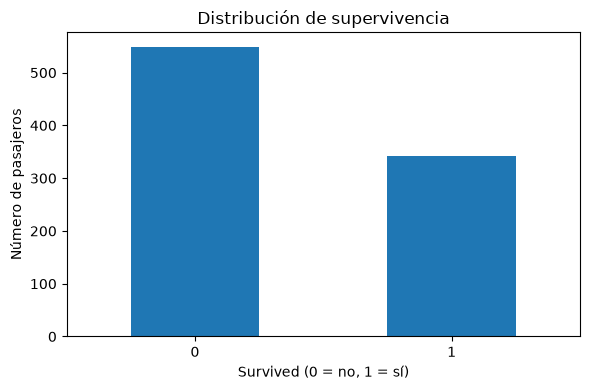

Tasa de supervivencia: 38.4%


In [9]:
survival_counts = titanic["Survived"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6, 4))
survival_counts.plot(kind="bar", ax=ax)
ax.set_title("Distribución de supervivencia")
ax.set_xlabel("Survived (0 = no, 1 = sí)")
ax.set_ylabel("Número de pasajeros")
plt.xticks(rotation=0)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "01_distribucion_supervivencia.png", dpi=180, bbox_inches="tight")
plt.show()

print(f"Tasa de supervivencia: {titanic['Survived'].mean():.1%}")


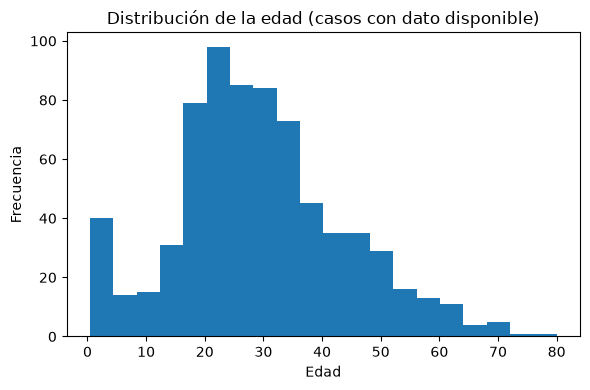

Edad válida en 714 de 891 registros.


In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
titanic["Age"].dropna().plot(kind="hist", bins=20, ax=ax)
ax.set_title("Distribución de la edad (casos con dato disponible)")
ax.set_xlabel("Edad")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "02_distribucion_age.png", dpi=180, bbox_inches="tight")
plt.show()

print(f"Edad válida en {titanic['Age'].notna().sum()} de {len(titanic)} registros.")


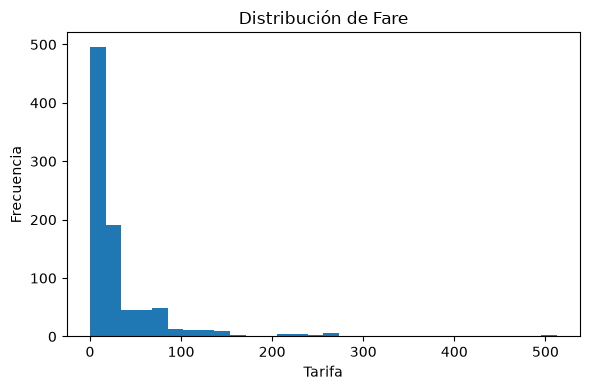

min      0.00
25%      7.91
50%     14.45
75%     31.00
max    512.33
Name: Fare, dtype: float64


In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
titanic["Fare"].plot(kind="hist", bins=30, ax=ax)
ax.set_title("Distribución de Fare")
ax.set_xlabel("Tarifa")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "03_distribucion_fare.png", dpi=180, bbox_inches="tight")
plt.show()

print(titanic["Fare"].describe()[["min", "25%", "50%", "75%", "max"]].round(2))


## 7. Relaciones simples: supervivencia por sexo y clase

Estas comparaciones son **descriptivas**. Permiten detectar patrones que después podrán estudiarse con mayor profundidad, pero no establecen causas.

,n,supervivencia_pct
Sex,,
female,314,74.2
male,577,18.9


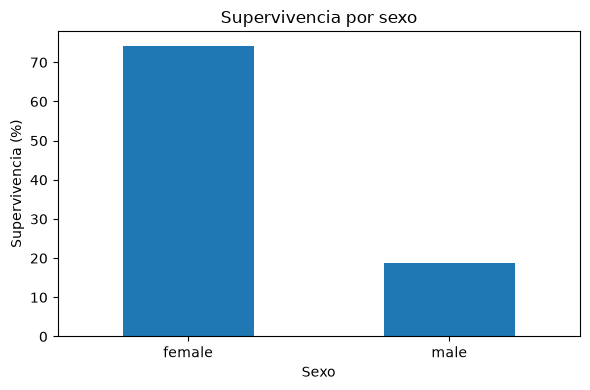

In [12]:
supervivencia_sexo = (titanic.groupby("Sex")["Survived"].agg(["count", "mean"]) * pd.Series({"count": 1, "mean": 100})).rename(columns={"count": "n", "mean": "supervivencia_pct"})
supervivencia_sexo["n"] = supervivencia_sexo["n"].astype(int)
display(supervivencia_sexo.round(1))
supervivencia_sexo.round(2).to_csv(OUTPUTS_DIR / "supervivencia_por_sexo.csv", index_label="Sex")

fig, ax = plt.subplots(figsize=(6, 4))
supervivencia_sexo["supervivencia_pct"].plot(kind="bar", ax=ax)
ax.set_title("Supervivencia por sexo")
ax.set_xlabel("Sexo")
ax.set_ylabel("Supervivencia (%)")
plt.xticks(rotation=0)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "04_supervivencia_por_sexo.png", dpi=180, bbox_inches="tight")
plt.show()


,n,supervivencia_pct
Pclass,,
1,216,63.0
2,184,47.3
3,491,24.2


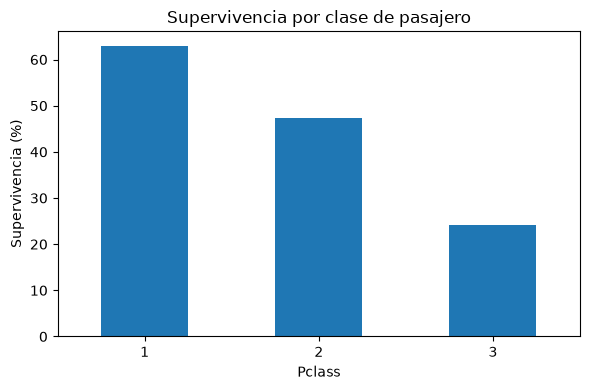

In [13]:
supervivencia_clase = titanic.groupby("Pclass")["Survived"].agg(["count", "mean"])
supervivencia_clase["supervivencia_pct"] = supervivencia_clase["mean"] * 100
supervivencia_clase = supervivencia_clase.rename(columns={"count": "n"})[["n", "supervivencia_pct"]]
display(supervivencia_clase.round(1))
supervivencia_clase.round(2).to_csv(OUTPUTS_DIR / "supervivencia_por_clase.csv", index_label="Pclass")

fig, ax = plt.subplots(figsize=(6, 4))
supervivencia_clase["supervivencia_pct"].plot(kind="bar", ax=ax)
ax.set_title("Supervivencia por clase de pasajero")
ax.set_xlabel("Pclass")
ax.set_ylabel("Supervivencia (%)")
plt.xticks(rotation=0)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "05_supervivencia_por_clase.png", dpi=180, bbox_inches="tight")
plt.show()


### Lectura exploratoria inicial

En este archivo aparecen diferencias descriptivas marcadas en la proporción de supervivencia según `Sex` y `Pclass`. Estas diferencias son **pistas analíticas**, no explicaciones causales. En la fase siguiente convendrá revisar posibles relaciones entre estas variables y otras características del pasajero, además de controlar la influencia de los datos faltantes.

## 8. Edad y supervivencia

La edad presenta valores faltantes, por lo que cualquier comparación debe indicar explícitamente cuántos casos válidos se utilizan.

,count,mean,median,std
Survived,,,,
0,424,30.63,28.0,14.17
1,290,28.34,28.0,14.95


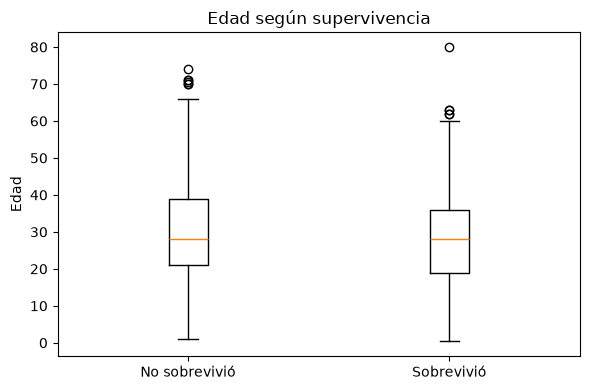

In [14]:
edad_supervivencia = titanic.groupby("Survived")["Age"].agg(["count", "mean", "median", "std"]).round(2)
display(edad_supervivencia)
edad_supervivencia.to_csv(OUTPUTS_DIR / "edad_segun_supervivencia.csv", index_label="Survived")

age_groups = [
    titanic.loc[titanic["Survived"] == 0, "Age"].dropna(),
    titanic.loc[titanic["Survived"] == 1, "Age"].dropna(),
]
fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot(age_groups, tick_labels=["No sobrevivió", "Sobrevivió"])
ax.set_title("Edad según supervivencia")
ax.set_ylabel("Edad")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "06_edad_segun_supervivencia.png", dpi=180, bbox_inches="tight")
plt.show()


## 9. Variable derivada: tamaño del grupo familiar

**Decisión documentada:** se crea `FamilySize = SibSp + Parch + 1`. El `+1` representa al propio pasajero. La variable se deriva mediante código y no modifica el archivo original.

,n,supervivencia_pct
FamilySize,,
1,537,30.4
2,161,55.3
3,102,57.8
4,29,72.4
5,15,20.0
6,22,13.6
7,12,33.3
8,6,0.0
11,7,0.0


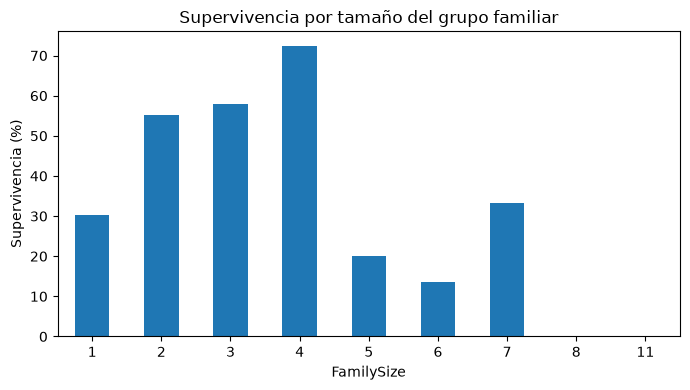

In [15]:
titanic["FamilySize"] = titanic["SibSp"] + titanic["Parch"] + 1

family_summary = titanic.groupby("FamilySize")["Survived"].agg(["count", "mean"])
family_summary["supervivencia_pct"] = family_summary["mean"] * 100
family_summary = family_summary.rename(columns={"count": "n"})[["n", "supervivencia_pct"]]
display(family_summary.round(1))
family_summary.round(2).to_csv(OUTPUTS_DIR / "supervivencia_por_family_size.csv", index_label="FamilySize")

# El dataset con la variable derivada se guarda como dato procesado; el archivo original permanece intacto.
titanic.to_csv(PROCESS_DIR / "titanic_eda_process.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4))
family_summary["supervivencia_pct"].plot(kind="bar", ax=ax)
ax.set_title("Supervivencia por tamaño del grupo familiar")
ax.set_xlabel("FamilySize")
ax.set_ylabel("Supervivencia (%)")
plt.xticks(rotation=0)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "07_supervivencia_por_family_size.png", dpi=180, bbox_inches="tight")
plt.show()


## 10. Revisión sencilla de posibles outliers con IQR

Detectar un valor extremo **no equivale a declarar un error**. Aquí solo se identifican casos que podrían requerir una revisión posterior.

In [16]:
def resumen_outliers_iqr(serie: pd.Series) -> pd.Series:
    s = serie.dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    mask = (s < limite_inferior) | (s > limite_superior)
    return pd.Series({
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "n_posibles_outliers": int(mask.sum()),
        "pct_posibles_outliers": float(mask.mean() * 100),
    })

outliers = pd.DataFrame({
    "Age": resumen_outliers_iqr(titanic["Age"]),
    "Fare": resumen_outliers_iqr(titanic["Fare"]),
}).T

display(outliers.round(2))
outliers.round(2).to_csv(OUTPUTS_DIR / "outliers_iqr.csv", index_label="variable")


,q1,q3,iqr,limite_inferior,limite_superior,n_posibles_outliers,pct_posibles_outliers
Age,20.12,38.0,17.88,-6.69,64.81,11.0,1.54
Fare,7.91,31.0,23.09,-26.72,65.63,116.0,13.02


## 11. Figuras de síntesis utilizadas en el informe

Para mantener **coherencia entre el notebook y el informe**, se reproducen en dos figuras compactas las visualizaciones que aparecen en las secciones III y IV de la ficha del proyecto.

- **Figura 1:** calidad mínima y distribuciones univariadas (`missingness`, `Survived`, `Age`, `Fare`).
- **Figura 2:** relaciones descriptivas vinculadas a preguntas (`Sex`, `Pclass`, `Age` y `FamilySize`).

Las figuras no reemplazan las visualizaciones individuales anteriores: las sintetizan para el informe y conservan exactamente la misma lógica exploratoria.

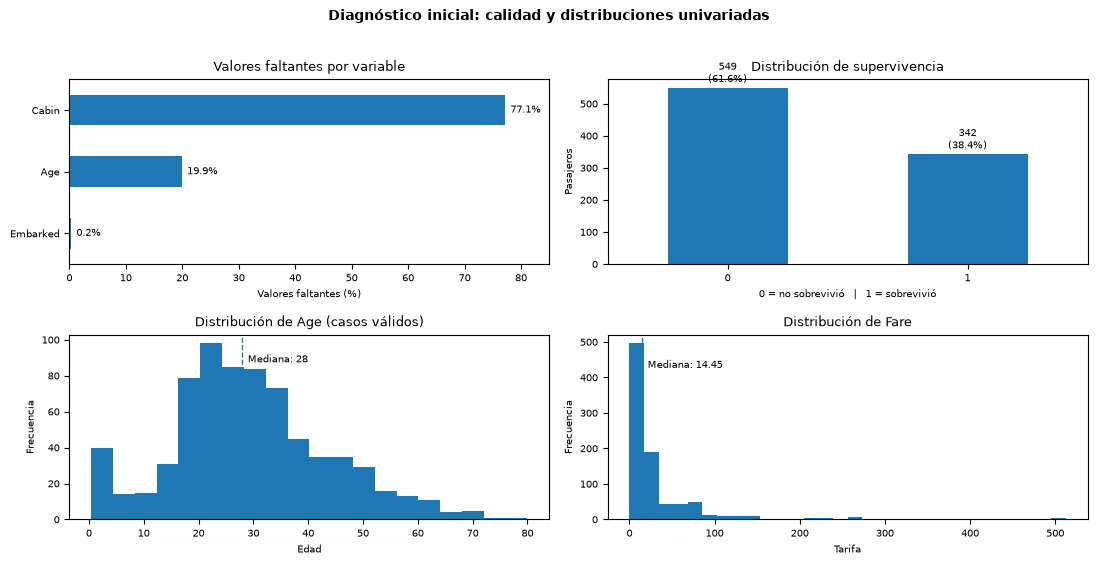

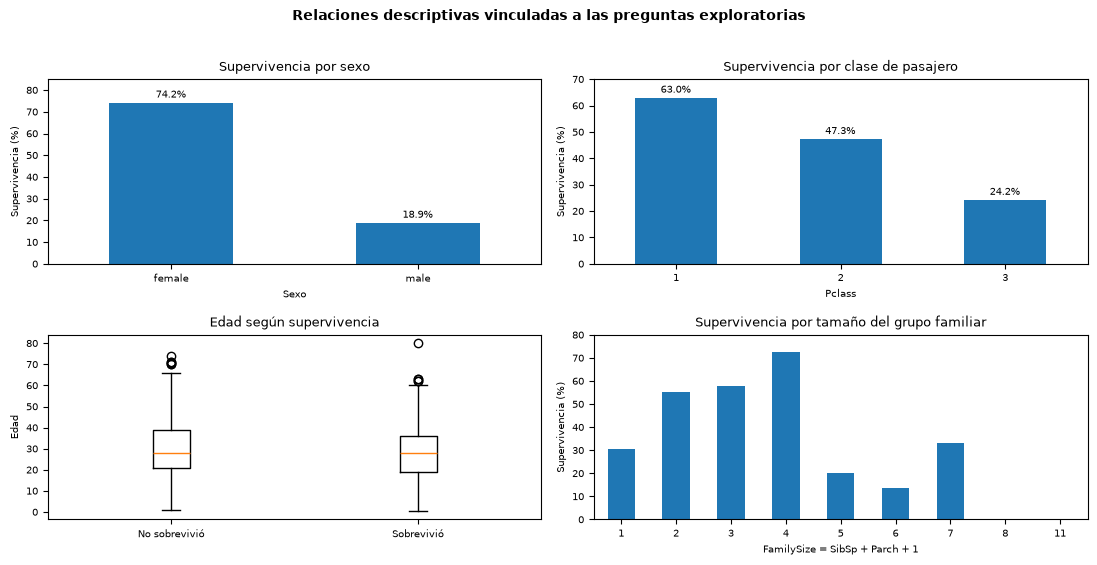

In [17]:
# Figuras de síntesis utilizadas en el informe
plt.rcParams.update({
    "font.size": 7.5,
    "axes.titlesize": 9.0,
    "axes.labelsize": 7.5,
    "xtick.labelsize": 7.0,
    "ytick.labelsize": 7.0,
    "legend.fontsize": 7.0,
    "figure.titlesize": 10.0,
})

# ---------------- Figura 1: calidad + distribuciones univariadas ----------------
fig, axes = plt.subplots(2, 2, figsize=(11.0, 5.6))

missing_pct = titanic.isna().mean().mul(100)
missing_pct = missing_pct[missing_pct > 0].sort_values()
ax = axes[0, 0]
missing_pct.plot(kind="barh", ax=ax, legend=False)
ax.set_title("Valores faltantes por variable")
ax.set_xlabel("Valores faltantes (%)")
ax.set_ylabel("")
ax.set_xlim(0, 85)
for i, v in enumerate(missing_pct.values):
    ax.text(v + 1.0, i, f"{v:.1f}%", va="center", fontsize=7)

ax = axes[0, 1]
counts = titanic["Survived"].value_counts().sort_index()
counts.plot(kind="bar", ax=ax, legend=False)
ax.set_title("Distribución de supervivencia")
ax.set_xlabel("0 = no sobrevivió   |   1 = sobrevivió")
ax.set_ylabel("Pasajeros")
ax.tick_params(axis="x", rotation=0)
for cont in ax.containers:
    ax.bar_label(cont, labels=[f"{int(v)}\n({v/len(titanic)*100:.1f}%)" for v in cont.datavalues], padding=2, fontsize=7)

ax = axes[1, 0]
titanic["Age"].dropna().plot(kind="hist", bins=20, ax=ax)
ax.set_title("Distribución de Age (casos válidos)")
ax.set_xlabel("Edad")
ax.set_ylabel("Frecuencia")
ax.axvline(titanic["Age"].median(), linestyle="--", linewidth=1)
ax.text(titanic["Age"].median() + 1, ax.get_ylim()[1] * 0.85, f"Mediana: {titanic['Age'].median():.0f}", fontsize=7)

ax = axes[1, 1]
titanic["Fare"].plot(kind="hist", bins=30, ax=ax)
ax.set_title("Distribución de Fare")
ax.set_xlabel("Tarifa")
ax.set_ylabel("Frecuencia")
ax.axvline(titanic["Fare"].median(), linestyle="--", linewidth=1)
ax.text(titanic["Fare"].median() + 7, ax.get_ylim()[1] * 0.82, f"Mediana: {titanic['Fare'].median():.2f}", fontsize=7)

fig.suptitle("Diagnóstico inicial: calidad y distribuciones univariadas", y=0.995, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.97], h_pad=1.5, w_pad=1.4)
fig.savefig(FIGURES_DIR / "08_figura_1_estado_inicial_titanic.png", dpi=220, bbox_inches="tight")
plt.show()

# ---------------- Figura 2: relaciones descriptivas ----------------
fig, axes = plt.subplots(2, 2, figsize=(11.0, 5.6))

sex = titanic.groupby("Sex")["Survived"].agg(["count", "mean"])
sex["pct"] = sex["mean"] * 100
ax = axes[0, 0]
sex["pct"].plot(kind="bar", ax=ax, legend=False)
ax.set_title("Supervivencia por sexo")
ax.set_xlabel("Sexo")
ax.set_ylabel("Supervivencia (%)")
ax.set_ylim(0, 85)
ax.tick_params(axis="x", rotation=0)
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.1f%%", padding=2, fontsize=7)

pcl = titanic.groupby("Pclass")["Survived"].agg(["count", "mean"])
pcl["pct"] = pcl["mean"] * 100
ax = axes[0, 1]
pcl["pct"].plot(kind="bar", ax=ax, legend=False)
ax.set_title("Supervivencia por clase de pasajero")
ax.set_xlabel("Pclass")
ax.set_ylabel("Supervivencia (%)")
ax.set_ylim(0, 70)
ax.tick_params(axis="x", rotation=0)
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.1f%%", padding=2, fontsize=7)

ax = axes[1, 0]
age_groups = [
    titanic.loc[titanic["Survived"] == 0, "Age"].dropna(),
    titanic.loc[titanic["Survived"] == 1, "Age"].dropna(),
]
ax.boxplot(age_groups, tick_labels=["No sobrevivió", "Sobrevivió"])
ax.set_title("Edad según supervivencia")
ax.set_ylabel("Edad")
ax.set_xlabel("")

family_summary = titanic.groupby("FamilySize")["Survived"].agg(["count", "mean"])
family_summary["pct"] = family_summary["mean"] * 100
ax = axes[1, 1]
family_summary["pct"].plot(kind="bar", ax=ax, legend=False)
ax.set_title("Supervivencia por tamaño del grupo familiar")
ax.set_xlabel("FamilySize = SibSp + Parch + 1")
ax.set_ylabel("Supervivencia (%)")
ax.set_ylim(0, 80)
ax.tick_params(axis="x", rotation=0)

fig.suptitle("Relaciones descriptivas vinculadas a las preguntas exploratorias", y=0.995, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.97], h_pad=1.5, w_pad=1.4)
fig.savefig(FIGURES_DIR / "09_figura_2_relaciones_titanic.png", dpi=220, bbox_inches="tight")
plt.show()


## 12. Síntesis de hallazgos, limitaciones y decisiones

### Qué se encontró
- El archivo contiene 891 pasajeros y 12 variables de tipos diversos.
- `Age`, `Cabin` y `Embarked` presentan valores faltantes; `Cabin` concentra la mayor ausencia.
- La supervivencia global es menor al 50 % y aparecen diferencias descriptivas marcadas según `Sex` y `Pclass`.
- `Fare` es fuertemente asimétrica y contiene valores extremos que conviene tratar con cautela.
- `FamilySize` permite explorar la composición familiar sin modificar el archivo original.

### Decisiones metodológicas registradas
- No imputar ni eliminar nulos automáticamente en esta fase.
- No excluir outliers solo por una regla estadística; primero se documentan.
- Interpretar las asociaciones como descriptivas, sin atribuir causalidad.
- Conservar `Titanic.csv` en `data/input/` y exportar transformaciones únicamente a `data/process/`.
- Guardar las figuras en `figures/` y las tablas/resúmenes en `outputs/`.

### Limitaciones
El dataset es observacional e histórico, contiene información incompleta y no permite atribuir causalidad a los patrones explorados. Además, este notebook corresponde a un **avance formativo**, por lo que prioriza diagnóstico, documentación y planificación por sobre un EDA exhaustivo.


In [18]:
resumen_md = f"""# Resumen EDA Titanic\n\n- Registros: {len(titanic)}\n- Variables originales: {raw.shape[1]}\n- Tasa de supervivencia: {titanic['Survived'].mean():.1%}\n- Nulos en Age: {titanic['Age'].isna().sum()} ({titanic['Age'].isna().mean():.1%})\n- Nulos en Cabin: {titanic['Cabin'].isna().sum()} ({titanic['Cabin'].isna().mean():.1%})\n- Nulos en Embarked: {titanic['Embarked'].isna().sum()} ({titanic['Embarked'].isna().mean():.1%})\n- Variable derivada: FamilySize = SibSp + Parch + 1\n\nLas asociaciones observadas son descriptivas y no implican causalidad.\n"""
(OUTPUTS_DIR / "resumen_eda.md").write_text(resumen_md, encoding="utf-8")
print("Resumen exportado:", OUTPUTS_DIR / "resumen_eda.md")
print("Dato procesado:", PROCESS_DIR / "titanic_eda_process.csv")
print("Figuras generadas:", len(list(FIGURES_DIR.glob("*.png"))))
print("Archivos de salida:", len(list(OUTPUTS_DIR.iterdir())))


Resumen exportado: C:\Github\Universidad\mcdi503-exploraci-n-inteligente\Semana1\Formativa1\outputs\resumen_eda.md
Dato procesado: C:\Github\Universidad\mcdi503-exploraci-n-inteligente\Semana1\Formativa1\data\process\titanic_eda_process.csv
Figuras generadas: 9
Archivos de salida: 15


## 13. Checklist de reproducibilidad de esta entrega

- [x] Pregunta y alcance analítico explícitos.
- [x] Dataset identificado y unidad de análisis descrita.
- [x] Estructura organizada por secciones narrativas y de código.
- [x] Entrada original ubicada en `data/input/Titanic.csv`.
- [x] Datos derivados guardados en `data/process/`.
- [x] Todas las imágenes generadas se guardan en `figures/`.
- [x] Notebook almacenado en `notebooks/`.
- [x] Tablas, CSV, resumen Markdown y manifiesto se guardan en `outputs/`.
- [x] Reportes separados en `Reports/`.
- [x] Tipos de variables revisados.
- [x] Nulos, duplicados, rangos y categorías inspeccionados.
- [x] Descriptivos y visualizaciones vinculados a preguntas.
- [x] Al menos una relación entre variables explorada.
- [x] Transformación (`FamilySize`) explicada y reproducible.
- [x] Archivo de entrada identificado mediante hash SHA-256.
- [x] Versiones del entorno registradas.
- [x] Hallazgos, decisiones y limitaciones documentados.
- [x] Ejecución compatible con **Jupyter Notebook/JupyterLab**, sin dependencias específicas de servicios externos.

**Ejecución esperada:** instalar `requirements.txt`, verificar `data/input/Titanic.csv`, abrir `notebooks/mcdi503_f1f_eda_titanic.ipynb` en Jupyter y ejecutar todas las celdas en orden.


## Referencias utilizadas para orientar el procedimiento

- Paraíso, S. (2026). *Resumen aplicado del libro: EDA mínimo viable* [Apunte]. Universidad Andrés Bello.
- Paraíso, S. (2026). *Checklist notebook reproducible* [Infografía]. Universidad Andrés Bello.
- Paraíso, S. (2026). *Tres errores típicos en EDA* [Podcast]. Universidad Andrés Bello.

> El dataset `Titanic.csv` corresponde al archivo proporcionado por la asignatura para el desarrollo de la actividad.